# Attention Implementation

Attention Simple Analogy (Library Example).
1. Query: What book you are searching for?
2. Key: Title of the book in the library
3. Value: Contents of the book


In [ ]:
import numpy as np

In [ ]:
def softmax(x):
  "compute softmax function"
  exp_x = np.exp(x - np.max(x))
  return exp_x / np.sum(exp_x)

In [ ]:
def attention(query,key,values):
  d= query.shape[-1]
  #calculate the score
  score = np.dot(key,query)
  result = score/(d**(1/2))
  attention_weight = softmax(result)

  context_weight = np.dot(attention_weight,values)
  return attention_weight,context_weight

In [ ]:
query = np.array([1.0, 0.0, 1.0])

keys = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 2.0, 0.0],
    [1.0, 1.0, 0.0]
])

values = np.array([
    [10, 0],
    [0, 20],
    [5, 5]
])

attent,context = attention(query, keys, values)
print("attention weight:",attent)
print("context weight:",context)

attention weight: [0.53289684 0.16794345 0.29915971]
context weight: [6.82476694 4.85466756]


In [ ]:
!pip install bertviz

In [12]:
from transformers import AutoTokenizer, AutoModel
from bertviz import head_view,model_view

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

text = "I ordered food and it tasted awesome"

inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs)

attentions = outputs.attentions

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

model_view(attentions, tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

In [10]:
head_view(attentions, tokens)

<IPython.core.display.Javascript object>

# Positional Encoding (Visualization)

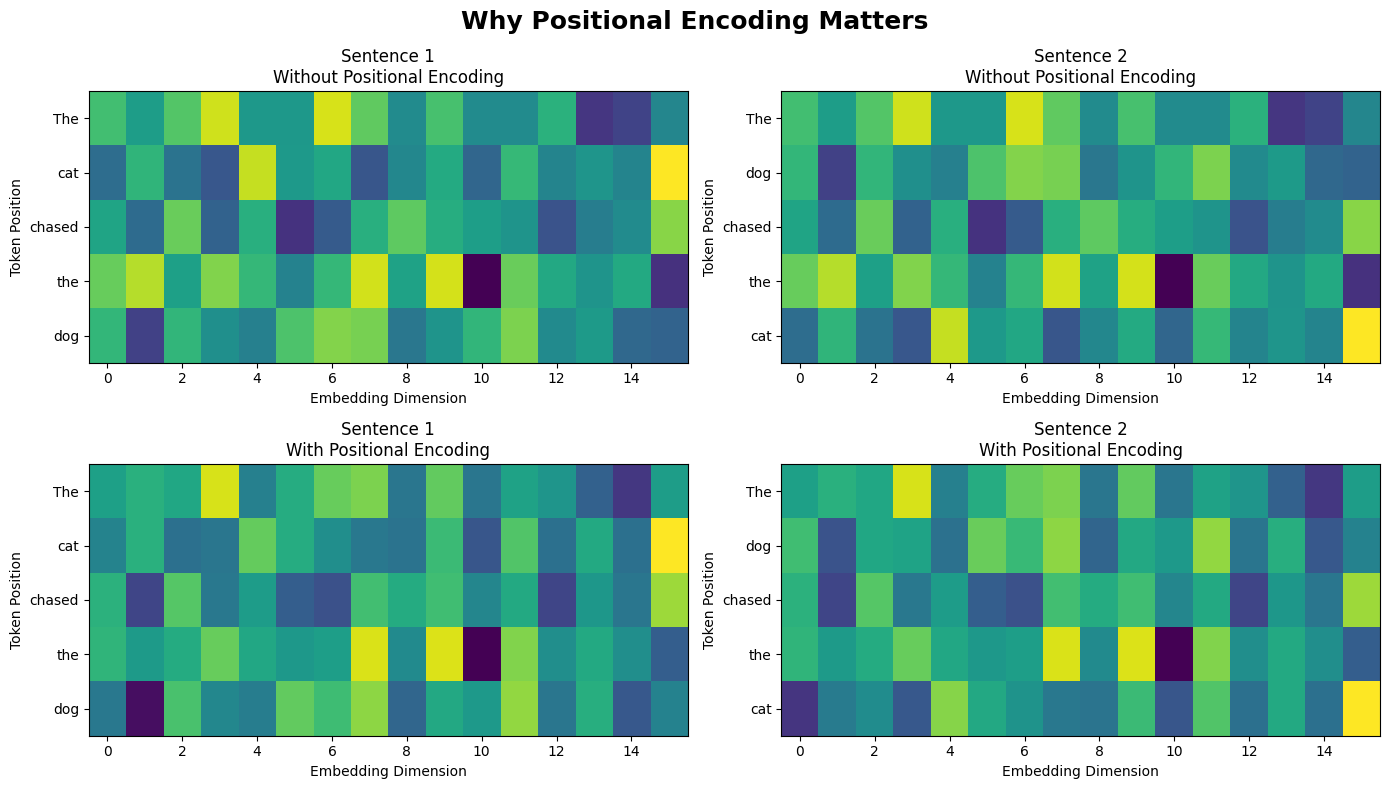

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sentence1 = ["The", "cat", "chased", "the", "dog"]
sentence2 = ["The", "dog", "chased", "the", "cat"]

d_model = 16
np.random.seed(42)
vocab = sorted(set(sentence1 + sentence2))
word_embeddings = {
    word: np.random.randn(d_model)
    for word in vocab
}

emb1 = np.array([word_embeddings[w] for w in sentence1])
emb2 = np.array([word_embeddings[w] for w in sentence2])

def positional_encoding(max_len, d_model):
    position = np.arange(max_len)[:, np.newaxis]

    div_term = np.exp(
        np.arange(0, d_model, 2) *
        (-np.log(10000.0) / d_model)
    )

    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

pe = positional_encoding(len(sentence1), d_model)

final1 = emb1 + pe
final2 = emb2 + pe

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

im1 = ax[0,0].imshow(emb1, aspect='auto', cmap='viridis')
ax[0,0].set_title("Sentence 1\nWithout Positional Encoding")
ax[0,0].set_yticks(range(len(sentence1)))
ax[0,0].set_yticklabels(sentence1)

im2 = ax[0,1].imshow(emb2, aspect='auto', cmap='viridis')
ax[0,1].set_title("Sentence 2\nWithout Positional Encoding")
ax[0,1].set_yticks(range(len(sentence2)))
ax[0,1].set_yticklabels(sentence2)

im3 = ax[1,0].imshow(final1, aspect='auto', cmap='viridis')
ax[1,0].set_title("Sentence 1\nWith Positional Encoding")
ax[1,0].set_yticks(range(len(sentence1)))
ax[1,0].set_yticklabels(sentence1)

im4 = ax[1,1].imshow(final2, aspect='auto', cmap='viridis')
ax[1,1].set_title("Sentence 2\nWith Positional Encoding")
ax[1,1].set_yticks(range(len(sentence2)))
ax[1,1].set_yticklabels(sentence2)

for a in ax.ravel():
    a.set_xlabel("Embedding Dimension")
    a.set_ylabel("Token Position")

plt.suptitle(
    "Why Positional Encoding Matters",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Transformer High level Architecture.**

```
Input Sentence
      ↓
  Tokenizer
      ↓
  Token IDs
      ↓
 Embedding Layer
      ↓
Positional Encoding
      ↓
Transformer Block × N
      ↓
 Linear Layer
      ↓
   Softmax
      ↓
 Output Token
```



**Transformer Block**

```
Input
  ↓
Multi-Head Self-Attention
  ↓
Add & LayerNorm
  ↓
Feed Forward Network
  ↓
Add & LayerNorm
  ↓
Output
```

**Multi-Head Attention** - Captures relationships between tokens.

**Residual Connections** - Help preserve information flow and stabilize training.

**Layer Normalization** - Improves convergence and training stability.

**Feed Forward Network** - Transforms token representations into richer features.